In [5]:
import numpy as np, pandas as pd, tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. 데이터 로드
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/TSLA.csv')
data = df['Close'].values.reshape(-1, 1)

In [23]:
train_size = int(len(data) * 0.8)
window = 12

print(train_size)

train_data = data[:train_size]
test_data = data[train_size - window:]

2364


In [24]:
# 3. 정규화 (오직 Train 데이터로만 기준을 잡음)

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)
# transform: Test 데이터는 Train의 기준을 그대로 빌려서 변환만! (미래 정보 누수 방지)
test_scaled = scaler.transform(test_data)

In [26]:
#4. 순환 데이터(시퀀스) 생성

def create_sequence(dataset, window_size):
    X, y = [], []
    for i in range(len(dataset) - window_size):
        X.append(dataset[i : i + window_size])
        y.append(dataset[i + window_size])
    return np.array(X), np.array(y)

X_train, y_train = create_sequence(train_scaled, window)
X_test, y_test = create_sequence(test_scaled, window)

print("X_train :", X_train.shape)
print("X_test :", X_test.shape)

X_train : (2352, 12, 1)
X_test : (592, 12, 1)


In [14]:
# 5. LSTM 모델 구성 및 학습

model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(window, 1)),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=1)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


294/294 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0060
Epoch 2/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0011
Epoch 3/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0011
Epoch 4/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 8.8035e-04
Epoch 5/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.1312e-04
Epoch 6/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.2510e-04
Epoch 7/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 6.6661e-04
Epoch 8/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 5.9425e-04
Epoch 9/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.5156e-04
Epoch 10/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.0201e-04
Epoch 11/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 4.5921e-04
Epoch 12/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4.8738e-04
Epoch 13/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.6313e-04
Epoch 14/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.9778e-04
Epoch 15/50
294/294 ━━━━

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


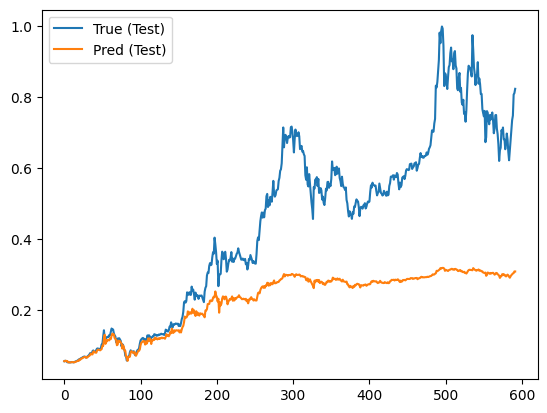

In [15]:

# 6. 예측 및 결과 확인
pred = model.predict(X_test)

plt.plot(scaler.inverse_transform(y_test), label='True (Test)')
plt.plot(scaler.inverse_transform(pred), label='Pred (Test)')
plt.legend()
plt.show()
